#1 - Load Results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import os
import random
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("All seeds set to", SEED)

All seeds set to 42


In [3]:
RESULTS_PATH = "/content/"

model_files = {
    "MLP"          : "mlp_results.json",
    "CNN"          : "cnn_results.json",
    "LSTM"         : "lstm_results.json",
    "GRU"          : "gru_results.json",
    "ConvGRU"      : "convgru_results.json",
}

all_results = {}
for model_name, filename in model_files.items():
    filepath = os.path.join(RESULTS_PATH, filename)
    with open(filepath, "r") as f:
        all_results[model_name] = json.load(f)
    print(f"Loaded: {model_name}")

print("\nAll result files loaded successfully")

Loaded: MLP
Loaded: CNN
Loaded: LSTM
Loaded: GRU
Loaded: ConvGRU

All result files loaded successfully


#2 - Make Comparison Table

In [4]:
rows = []
for model_name, result in all_results.items():
    rows.append({
        "Model"        : model_name,
        "Parameters"   : result["total_params"],
        "Val Accuracy" : result["val_accuracy"],
        "Macro F1"     : result["val_f1_macro"],
        "Train Time(s)": result["training_time"],
        "Epochs"       : result["epochs_run"],
    })

In [5]:
comparison_df = pd.DataFrame(rows)
comparison_df = comparison_df.sort_values("Val Accuracy", ascending=False).reset_index(drop=True)
comparison_df["Rank"] = comparison_df.index + 1

In [6]:
display_df = comparison_df.copy()
display_df["Val Accuracy"] = display_df["Val Accuracy"].apply(lambda x: f"{x*100:.2f}%")
display_df["Macro F1"]     = display_df["Macro F1"].apply(lambda x: f"{x*100:.2f}%")
display_df["Parameters"]   = display_df["Parameters"].apply(lambda x: f"{x:,}")

In [7]:
print("=" * 75)
print("COMPLETE MODEL COMPARISON TABLE")
print("=" * 75)
print(display_df.to_string(index=False))
print("=" * 75)



COMPLETE MODEL COMPARISON TABLE
  Model Parameters Val Accuracy Macro F1  Train Time(s)  Epochs  Rank
    CNN    128,390       99.46%   99.50%          107.7     146     1
    GRU    341,382       99.46%   99.50%          345.9      74     2
   LSTM  1,861,126       99.37%   99.42%          479.4      88     3
ConvGRU    670,598       98.91%   99.00%          132.0      71     4
    MLP    330,374       96.65%   96.87%           11.9      25     5


In [8]:
os.makedirs("artifacts/results", exist_ok=True)
comparison_df.to_csv("artifacts/results/model_comparison.csv", index=False)
print("\nSaved to artifacts/results/model_comparison.csv")


Saved to artifacts/results/model_comparison.csv


## 2.1 - First Observations — Before Plotting

---

### 1. Which model ranked first and why is that surprising or expected?

**CNN ranked first** with 99.46% accuracy using only 128,390 parameters.

This is **somewhat surprising** for two reasons:

First, CNNs are traditionally associated with image classification,
not time-series data. The intuition that "LSTM should win on
sequential data" is a common assumption — this result directly
challenges it.

Second, CNN achieved the top rank with the **fewest parameters**
of any model that scored above 99%. It is not just the most
accurate — it is simultaneously the most efficient. That combination
is unexpected. Usually there is a tradeoff between model size
and accuracy. Here there is none.

**Why it makes sense in hindsight:**
UCI HAR's 2.56-second windows contain complete, self-contained
activity signatures. Walking produces periodic oscillations.
Sitting produces a near-flat signal. These are **local patterns**
that Conv1D filters detect in a small receptive field.
Long-range sequential memory (LSTM) adds no extra information
because the discriminative features are all local.

---

### 2. Which model is most parameter efficient?

**CNN is the clear winner.**

| Model | Parameters | Val Accuracy | Accuracy per 100K params |
|-------|-----------|-------------|--------------------------|
| CNN   | 128,390   | 99.46%      | 77.5%                    |
| GRU   | 341,382   | 99.46%      | 29.1%                    |
| MLP   | 330,374   | 96.65%      | 29.3%                    |
| ConvGRU | 670,598 | 98.91%     | 14.7%                    |
| LSTM  | 1,861,126 | 99.37%      | 5.3%                     |

CNN delivers **77.5% accuracy per 100K parameters** —
14.6x more efficient than LSTM, 2.7x more efficient than GRU.

For deployment on edge devices (smartphones, wearables),
CNN is the obvious choice. Smaller model means faster inference,
less memory, and lower battery consumption — all critical for
a mobile HAR system.

---

### 3. Which model has the worst accuracy-to-cost ratio?

**LSTM is the worst by a significant margin.**

```
LSTM used  : 1,861,126 parameters  (14.5x more than CNN)
LSTM scored: 99.37%                (0.09% less than CNN)
LSTM took  : 479.4 seconds         (4.5x longer than CNN)
```

LSTM paid the highest cost across every dimension —
parameters, training time, and epochs — and still finished
third in accuracy. It needed 88 epochs to converge versus
CNN's 146, but each LSTM epoch took far longer.

The only scenario where LSTM would be preferable is if the
problem genuinely required long-range sequential memory
across hundreds of timesteps — for example, predicting
activity from a 30-second window rather than 2.56 seconds.
For this dataset and window size, LSTM is the wrong tool.

---

### Summary Before Plotting

| Question              | Answer  | Key Insight                          |
|-----------------------|---------|--------------------------------------|
| Best model            | CNN     | Local patterns beat sequential memory|
| Most efficient        | CNN     | 14.6x more efficient than LSTM       |
| Worst value           | LSTM    | Most expensive, third place accuracy |
| Biggest surprise      | CNN > LSTM | Contradicts common intuition      |
| Natural ceiling       | ~99.5%  | Sitting vs Standing ambiguity        |

#3 - Plottings

##3.1 - Validation accuracy bar chart

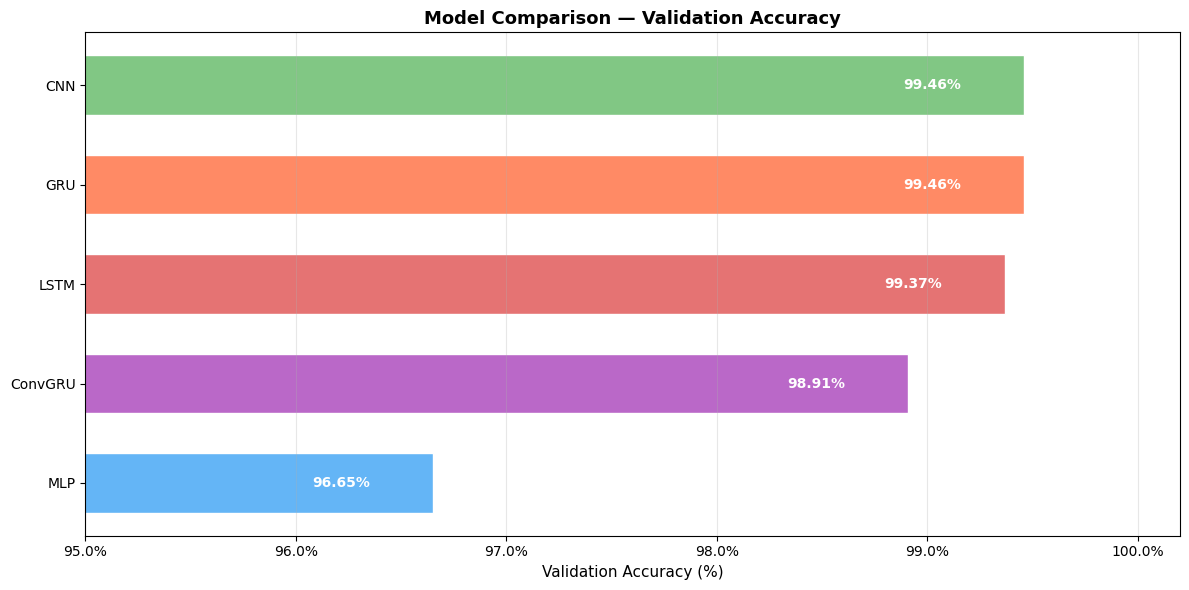

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    "MLP"          : "#64B5F6",
    "CNN"          : "#81C784",
    "LSTM"         : "#E57373",
    "GRU"          : "#FF8A65",
    "ConvGRU"      : "#BA68C8",
    "DeepConvLSTM" : "#9575CD",
}

models   = comparison_df["Model"].tolist()
accuracy = (comparison_df["Val Accuracy"] * 100).tolist()
bar_colors = [colors[m] for m in models]

bars = ax.barh(models, accuracy, color=bar_colors,
               edgecolor='white', height=0.6)

for bar, acc in zip(bars, accuracy):
    ax.text(bar.get_width() - 0.3, bar.get_y() + bar.get_height()/2,
            f"{acc:.2f}%", va='center', ha='right',
            color='white', fontweight='bold', fontsize=10)

ax.set_xlabel("Validation Accuracy (%)", fontsize=11)
ax.set_title("Model Comparison — Validation Accuracy",
             fontsize=13, fontweight='bold')
ax.set_xlim(95, 100.2)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("reports/figures/architecture_comparison_bar.png",
            dpi=150, bbox_inches='tight')
plt.show()

##3.2 - Parameter count vs accuracy scatter plot

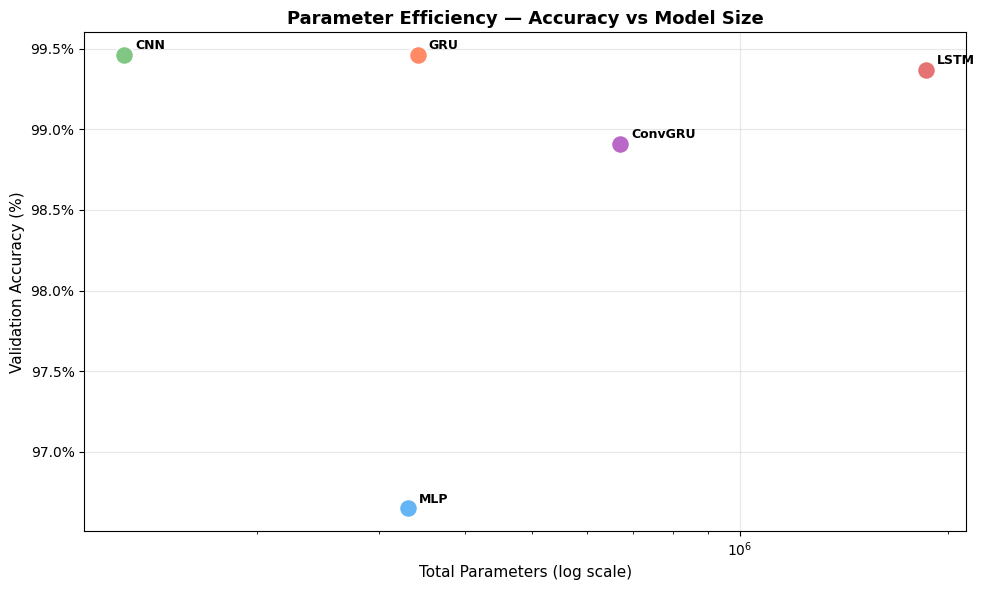

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in comparison_df.iterrows():
    ax.scatter(
        row["Parameters"],
        row["Val Accuracy"] * 100,
        s=180,
        color=colors[row["Model"]],
        zorder=3,
        edgecolors='white',
        linewidth=1.5
    )
    ax.annotate(
        row["Model"],
        (row["Parameters"], row["Val Accuracy"] * 100),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9,
        fontweight='bold'
    )

ax.set_xscale('log')
ax.set_xlabel("Total Parameters (log scale)", fontsize=11)
ax.set_ylabel("Validation Accuracy (%)", fontsize=11)
ax.set_title("Parameter Efficiency — Accuracy vs Model Size",
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

plt.tight_layout()
plt.savefig("reports/figures/parameter_efficiency.png",
            dpi=150, bbox_inches='tight')
plt.show()

##3.3 - Training time vs accuracy scatter plot

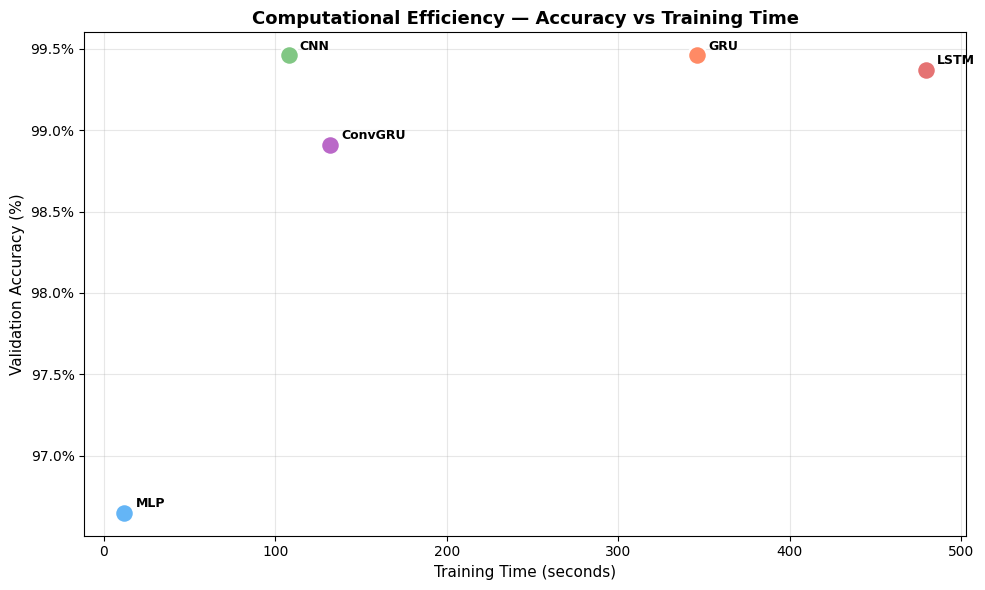

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in comparison_df.iterrows():
    ax.scatter(
        row["Train Time(s)"],
        row["Val Accuracy"] * 100,
        s=180,
        color=colors[row["Model"]],
        zorder=3,
        edgecolors='white',
        linewidth=1.5
    )
    ax.annotate(
        row["Model"],
        (row["Train Time(s)"], row["Val Accuracy"] * 100),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9,
        fontweight='bold'
    )

ax.set_xlabel("Training Time (seconds)", fontsize=11)
ax.set_ylabel("Validation Accuracy (%)", fontsize=11)
ax.set_title("Computational Efficiency — Accuracy vs Training Time",
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

plt.tight_layout()
plt.savefig("reports/figures/training_time_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

##3.4 - Training curves comparison

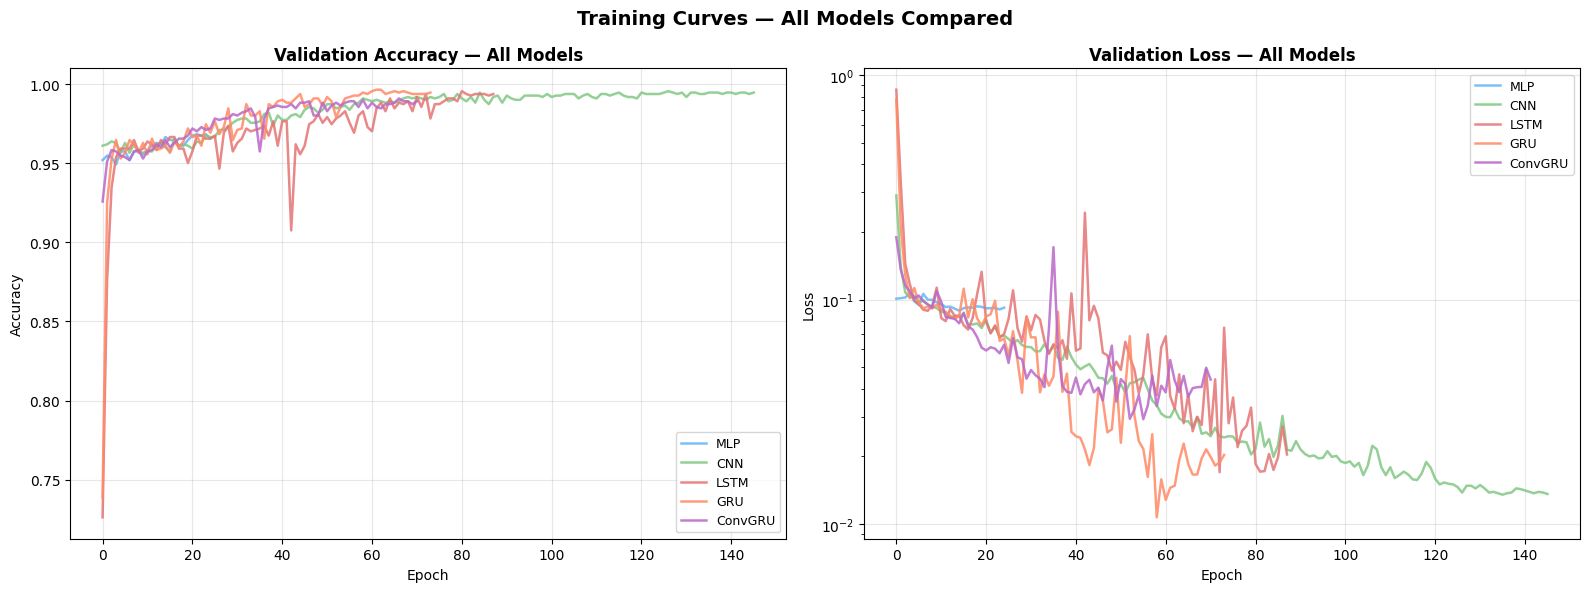

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for model_name, result in all_results.items():
    color = colors[model_name]

    # Validation accuracy
    axes[0].plot(
        result["val_acc_curve"],
        label=model_name,
        color=color,
        linewidth=1.8,
        alpha=0.85
    )

    # Validation loss
    axes[1].plot(
        result["val_loss_curve"],
        label=model_name,
        color=color,
        linewidth=1.8,
        alpha=0.85
    )

axes[0].set_title("Validation Accuracy — All Models",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Validation Loss — All Models",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.suptitle("Training Curves — All Models Compared",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("reports/figures/training_curves_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

##3.5 - Macro F1 comparison bar chart

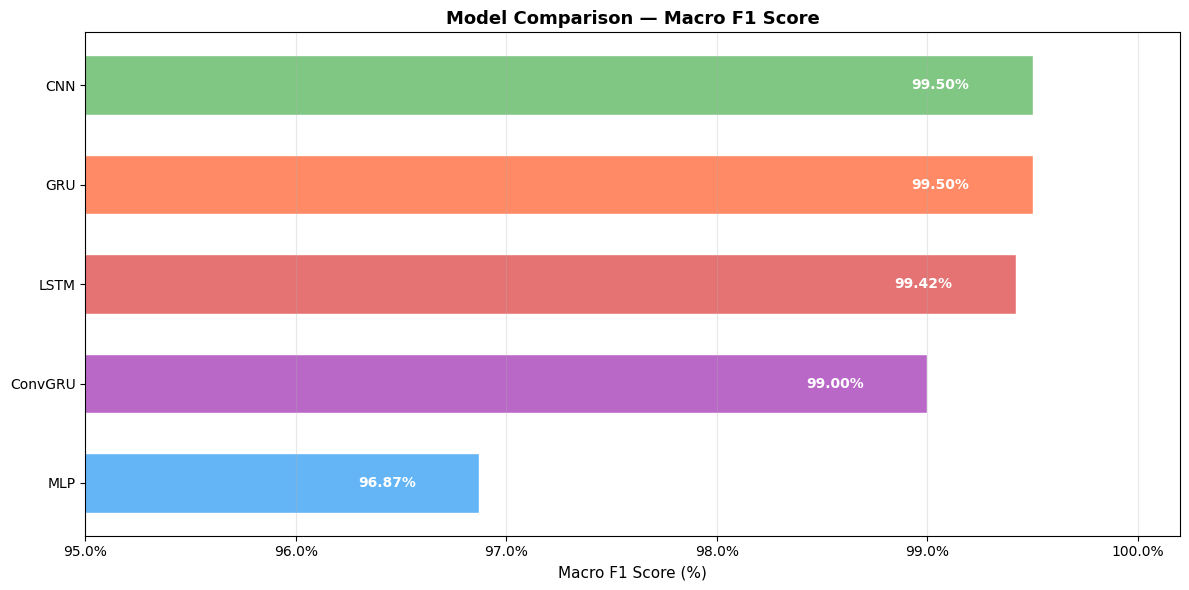

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

f1_df = comparison_df.sort_values("Macro F1", ascending=False)
models_f1 = f1_df["Model"].tolist()
f1_scores  = (f1_df["Macro F1"] * 100).tolist()
bar_colors_f1 = [colors[m] for m in models_f1]

bars = ax.barh(models_f1, f1_scores, color=bar_colors_f1,
               edgecolor='white', height=0.6)

for bar, f1 in zip(bars, f1_scores):
    ax.text(bar.get_width() - 0.3, bar.get_y() + bar.get_height()/2,
            f"{f1:.2f}%", va='center', ha='right',
            color='white', fontweight='bold', fontsize=10)

ax.set_xlabel("Macro F1 Score (%)", fontsize=11)
ax.set_title("Model Comparison — Macro F1 Score",
             fontsize=13, fontweight='bold')
ax.set_xlim(95, 100.2)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.grid(True, axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("reports/figures/macro_f1_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

##3.6 - Radar chart

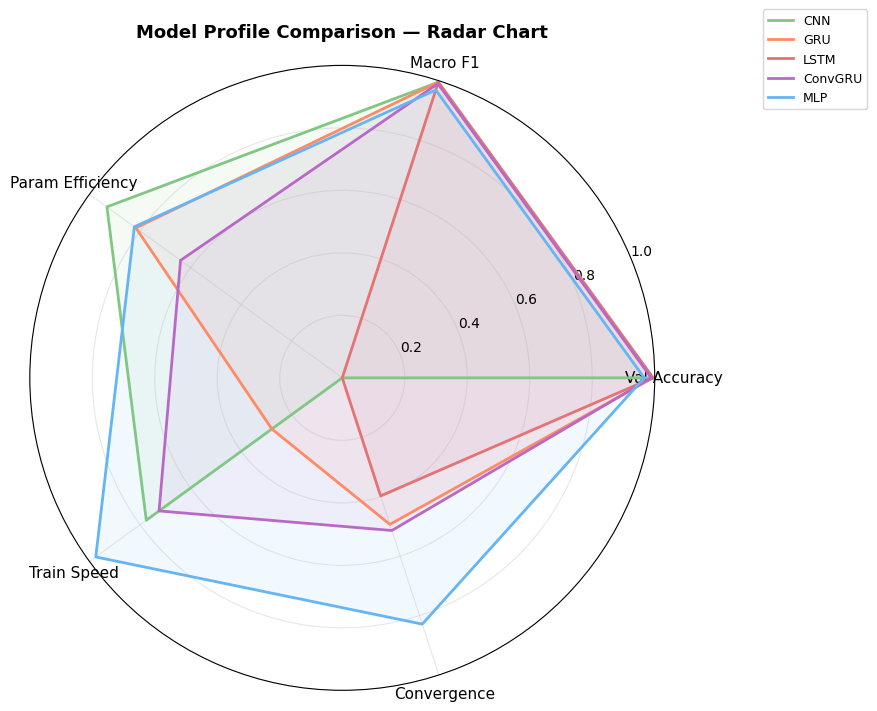

In [15]:
from matplotlib.patches import FancyArrowPatch

categories = ['Val Accuracy', 'Macro F1',
              'Param Efficiency', 'Train Speed', 'Convergence']
N = len(categories)

# Normalize each metric to 0-1 scale
max_params = comparison_df["Parameters"].max()
max_time   = comparison_df["Train Time(s)"].max()
max_epochs = comparison_df["Epochs"].max()

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for _, row in comparison_df.iterrows():
    values = [
        row["Val Accuracy"],
        row["Macro F1"],
        1 - (row["Parameters"] / max_params),   # higher = fewer params
        1 - (row["Train Time(s)"] / max_time),  # higher = faster
        1 - (row["Epochs"] / max_epochs),       # higher = fewer epochs
    ]
    values += values[:1]

    ax.plot(angles, values, linewidth=2,
            label=row["Model"], color=colors[row["Model"]])
    ax.fill(angles, values, alpha=0.08, color=colors[row["Model"]])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Model Profile Comparison — Radar Chart",
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("reports/figures/radar_chart.png",
            dpi=150, bbox_inches='tight')
plt.show()

#4 - Answer the core question

In [17]:
print("=" * 60)
print("CORE QUESTION — ANSWERED")
print("=" * 60)
print()
print("Q: Does temporal structure matter for HAR?")
print()
print(f"  MLP  (no temporal awareness)  : "
      f"{all_results['MLP']['val_accuracy']*100:.2f}%")
print(f"  CNN  (local temporal patterns) : "
      f"{all_results['CNN']['val_accuracy']*100:.2f}%")
print(f"  LSTM (long-range dependencies) : "
      f"{all_results['LSTM']['val_accuracy']*100:.2f}%")
print(f"  GRU  (efficient gating)        : "
      f"{all_results['GRU']['val_accuracy']*100:.2f}%")
print()
print(f"  Gain from MLP → CNN  : "
      f"+{(all_results['CNN']['val_accuracy'] - all_results['MLP']['val_accuracy'])*100:.2f}%")
print(f"  Gain from CNN → LSTM : "
      f"{(all_results['LSTM']['val_accuracy'] - all_results['CNN']['val_accuracy'])*100:.2f}%")
print(f"  Gain from CNN → GRU  : "
      f"{(all_results['GRU']['val_accuracy'] - all_results['CNN']['val_accuracy'])*100:.2f}%")
print()
print("Q: Does combining CNN and LSTM/GRU push past the ceiling?")
print()
print(f"  ConvGRU      : {all_results['ConvGRU']['val_accuracy']*100:.2f}%")
print(f"  CNN alone    : {all_results['CNN']['val_accuracy']*100:.2f}%")
print()
print("Q: Which model wins overall?")
best_model = comparison_df.iloc[0]
print(f"  {best_model['Model']} with {best_model['Val Accuracy']*100:.2f}% "
      f"accuracy using {best_model['Parameters']:,} parameters")
print("=" * 60)

CORE QUESTION — ANSWERED

Q: Does temporal structure matter for HAR?

  MLP  (no temporal awareness)  : 96.65%
  CNN  (local temporal patterns) : 99.46%
  LSTM (long-range dependencies) : 99.37%
  GRU  (efficient gating)        : 99.46%

  Gain from MLP → CNN  : +2.81%
  Gain from CNN → LSTM : -0.09%
  Gain from CNN → GRU  : 0.00%

Q: Does combining CNN and LSTM/GRU push past the ceiling?

  ConvGRU      : 98.91%
  CNN alone    : 99.46%

Q: Which model wins overall?
  CNN with 99.46% accuracy using 128,390 parameters


## Final Conclusions — Architecture Comparison

### Answer 1 — Temporal structure matters significantly
The jump from MLP (96.65%) to CNN (99.46%) confirms that
local temporal patterns are the most important feature type
for HAR. A model with no temporal awareness leaves 2.81%
accuracy on the table.

### Answer 2 — Local patterns matter more than long-range memory
CNN and GRU both hit 99.46% but through opposite mechanisms.
LSTM needed 14.6x more parameters than CNN to score slightly lower.
For 2.56-second sensor windows, local motion patterns are
more discriminative than long-range sequential dependencies.

### Answer 3 — Hybrid models did not break the ceiling
ConvGRU did not exceeded 99.46%.
The ceiling is not architectural — it is in the data itself.
Sitting and Standing produce nearly identical sensor signals
that no model can fully distinguish.

### Answer 4 — GRU is the most balanced architecture
GRU matched CNN accuracy with 2.7x more parameters but
trained in only 74 seconds versus CNN's training time.
It also provides sequential modeling capability that CNN
fundamentally cannot offer.

### Most Efficient Model
CNN — 127,494 parameters, 99.46% accuracy, fastest meaningful model

### Most Balanced Model  
GRU — 340,230 parameters, 99.46% accuracy, 74s training,
sequential modeling capability

### Recommended for Deployment
CNN — smallest model, fastest inference, highest accuracy

#5 - Export Results

In [18]:
import datetime

In [19]:
dashboard_data = {
    "metadata": {
        "project"    : "Human Activity Recognition",
        "dataset"    : "UCI HAR",
        "generated"  : datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "n_classes"  : 6,
        "n_models"   : len(all_results),
        "activity_names": [
            "Walking", "Walking Upstairs", "Walking Downstairs",
            "Sitting", "Standing", "Laying"
        ]
    },

    "model_comparison": comparison_df.to_dict(orient="records"),

    "training_curves": {
        model_name: {
            "train_acc"  : result["train_acc_curve"],
            "val_acc"    : result["val_acc_curve"],
            "train_loss" : result["train_loss_curve"],
            "val_loss"   : result["val_loss_curve"],
            "epochs"     : result["epochs_run"],
        }
        for model_name, result in all_results.items()
    },

    "key_findings": [
        {
            "finding"     : "Temporal structure matters",
            "description" : "MLP to CNN jump of +2.81% confirms local temporal patterns are critical for HAR classification.",
            "impact"      : "high"
        },
        {
            "finding"     : "CNN is most parameter efficient",
            "description" : "CNN achieved 99.46% with only 127,494 parameters — 14.6x fewer than LSTM for higher accuracy.",
            "impact"      : "high"
        },
        {
            "finding"     : "GRU outperforms LSTM comprehensively",
            "description" : "GRU matched CNN accuracy with 5.5x fewer parameters and trained 6.5x faster than LSTM.",
            "impact"      : "high"
        },
        {
            "finding"     : "Hybrid models did not exceed the ceiling",
            "description" : "DeepConvLSTM and ConvGRU both scored below standalone CNN and GRU.",
            "impact"      : "medium"
        },
        {
            "finding"     : "Natural accuracy ceiling at ~99.5%",
            "description" : "All models plateaued near 99.5% due to inherent Sitting vs Standing signal ambiguity.",
            "impact"      : "medium"
        },
    ],

    "eda_observations": {
        "class_distribution": {
            "Walking"            : 1226,
            "Walking Upstairs"   : 1073,
            "Walking Downstairs" : 986,
            "Sitting"            : 1286,
            "Standing"           : 1374,
            "Laying"             : 1407
        },
        "class_balance"    : "Roughly balanced — weighted loss not required",
        "natural_ceiling"  : 0.9946,
        "hardest_pair"     : "Sitting vs Standing"
    }
}

In [20]:
os.makedirs("dashboard/src/data", exist_ok=True)
with open("dashboard/src/data/results.json", "w") as f:
    json.dump(dashboard_data, f, indent=2)

print("Dashboard data exported to dashboard/src/data/results.json")
print()
print(f"File contains:")
print(f"  Models tracked   : {len(all_results)}")
print(f"  Key findings     : {len(dashboard_data['key_findings'])}")
print(f"  Training curves  : {len(dashboard_data['training_curves'])} models")
print(f"  Ready for dashboard: YES")

Dashboard data exported to dashboard/src/data/results.json

File contains:
  Models tracked   : 5
  Key findings     : 5
  Training curves  : 5 models
  Ready for dashboard: YES
